In [126]:
import pandas as pd
import seaborn as sns 
import umap
import matplotlib.pyplot as plt
import numpy as np

In [260]:
lv500 = pd.read_csv('results/VanillaVAE_dropna/latent_variables_epoch1000.csv')
lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV121,LV122,LV123,LV124,LV125,LV126,LV127,LV128,flyID,genotype
0,1.372615,-2.079071,5.314517,6.346415,3.576416,-1.511956,13.916572,3.237187,2.446653,9.822103,...,-6.805264,-5.291850,11.746210,-0.201597,-0.195801,-2.545389,4.856113,-1.145381,M119_M49_Ch17,attp40xQAb42_M
1,12.870952,-30.186596,27.765068,19.202953,22.676650,-22.796015,24.650703,16.509928,11.280396,12.122602,...,-0.411158,-29.050478,5.810594,-0.350509,6.152559,-0.207645,21.302590,-30.802023,M106_M15_Ch8,SwedArcxrepo_3_M
2,-7.010117,-24.002570,19.727152,-12.044909,1.467783,10.002118,-3.067422,-8.279963,9.121579,-3.207766,...,24.918890,-3.699180,14.603854,2.273524,-6.480107,6.861367,-9.932140,10.678501,M96_M54_Ch13,Swed>alrmvF
3,-20.637516,-33.254578,7.722467,-24.153288,-23.682230,18.356077,-2.066006,-11.588375,23.544813,-17.878270,...,18.227724,20.443026,-20.995852,8.490969,10.628320,-10.362025,-0.183787,-3.416682,M96_M50_Ch13,London>alrmM
4,-8.765019,-44.824562,20.930141,-20.153719,8.746166,-9.228594,4.001735,20.520327,21.903850,-9.818920,...,38.224430,9.859314,14.795849,28.427845,8.119950,35.634987,5.488190,-26.430626,M96_M80_Ch28,SwedArc>attp2F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,1.368336,-2.058063,5.298338,6.323928,3.655330,-1.549236,13.986897,3.312454,2.478303,9.852919,...,-6.800307,-5.357913,11.787381,-0.215078,-0.204519,-2.554927,4.940231,-1.059543,M106_M4_Ch7,elavQFxattp2_3_M
1202,-12.949490,-38.931873,14.013873,-5.880270,-7.589905,28.981504,-10.009447,-10.760073,30.640478,-12.308589,...,23.058685,2.805036,30.816298,23.648520,16.461529,0.888287,5.972688,8.814487,M96_M49_Ch6,SwedArc>alrmM
1203,-14.463966,-36.135525,39.011154,-8.450185,41.692772,28.389236,9.482563,0.711522,33.966220,-70.960250,...,31.715030,-59.214770,36.946545,-1.180962,20.689125,39.036194,-4.522789,-34.537490,M96_M55_Ch6,elav>attp2M
1204,-10.379683,-40.197040,29.526674,-14.197499,27.535234,11.361604,-17.857355,11.637393,9.008867,-29.252937,...,28.100666,8.980787,8.845073,11.509393,0.156714,23.721394,-17.021849,-10.091519,M96_M79_Ch3,London>attp2vF


In [ ]:
# lv500 = lv500.dropna(subset='genotype')
# lv500

In [205]:
lv500['genotype'].unique()

array(['attp40xQAb42_M', 'SwedArcxrepo_3_M', 'Swed>alrmvF',
       'London>alrmM', 'SwedArc>attp2F', 'attp2>nsybG4M',
       'attp2xQA40_1_F', 'Swed>attp2M', 'attp2xQA42_1_F', 'Swed>attp2F',
       'Londonxalrm_2_F', 'attp2xrepo_1_M', 'Londonxattp40_3_F',
       'London>attp2F', 'attp2xQA42_3_M', 'SwedArc>alrmM',
       'attp40xQAb40_M', 'attp2xQA40_3_M', 'Swedishxattp2_2_F',
       'elavQFxQA40_1_M', 'SwedArcxattp2_3_M', 'attp2xalrm_3_F',
       'Swedishxrepo_1_F', 'SwedArcxattp2_1_F', 'attp2xrepo_2_M',
       'Londonxrepo_3_M', 'Londonxattp2_3_M', 'Swed>nsybG4M',
       'elav>attp2F', 'elavQFxQA42_1_F', 'attp40xQAb42_F',
       'elavQFxattp2_1_M', 'elavQFxattp2_1_F', 'elavQFxattp2_3_M',
       'elavQFxQA42_1_M', 'SwedArcxrepo_3_F', 'attp2xalrm_1_M',
       'SwedArc>attp2M', 'attp2xQA42_3_F', 'attp2xalrm_3_M',
       'alrm>attp2M', 'London>nsybG4F', 'elavQFxQA42_3_F', 'London>elavF',
       'Swed>nsybG4vF', 'attp2xrepo_1_F', 'SwedArc>nsybG4F',
       'attp40xQA40_3_M', 'Londonxalrm_1_

<Axes: xlabel='LV30', ylabel='Density'>

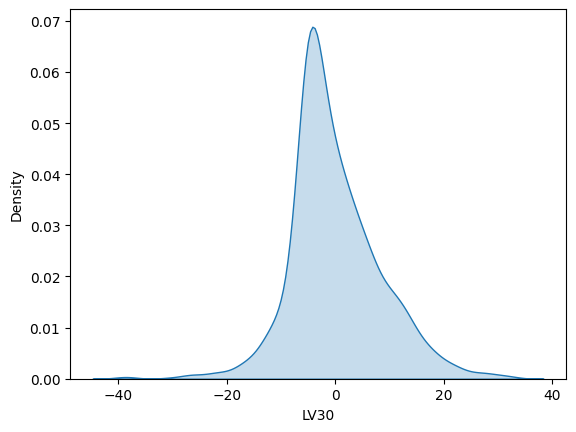

In [238]:
sns.kdeplot(x=lv500['LV30'], fill=True)

<Axes: xlabel='LV2', ylabel='Density'>

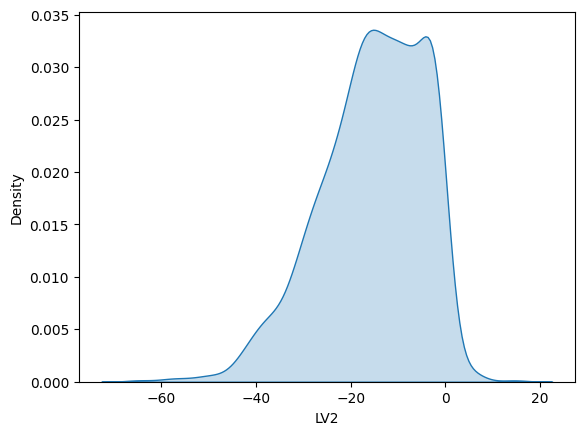

In [239]:
sns.kdeplot(x=lv500['LV2'], fill=True)

<Axes: xlabel='LV60', ylabel='Density'>

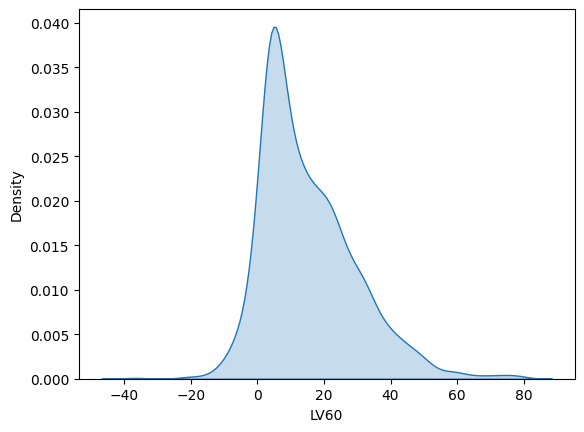

In [240]:
sns.kdeplot(x=lv500['LV60'], fill=True)

In [261]:
lv500['AD'] = np.where(
    (lv500['genotype'].str.contains('attp2', case=False, na=False)) | (lv500['genotype'].str.contains('attp4', case=False, na=False)), 
    'Control', 
    'AD')
lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV122,LV123,LV124,LV125,LV126,LV127,LV128,flyID,genotype,AD
0,1.372615,-2.079071,5.314517,6.346415,3.576416,-1.511956,13.916572,3.237187,2.446653,9.822103,...,-5.291850,11.746210,-0.201597,-0.195801,-2.545389,4.856113,-1.145381,M119_M49_Ch17,attp40xQAb42_M,Control
1,12.870952,-30.186596,27.765068,19.202953,22.676650,-22.796015,24.650703,16.509928,11.280396,12.122602,...,-29.050478,5.810594,-0.350509,6.152559,-0.207645,21.302590,-30.802023,M106_M15_Ch8,SwedArcxrepo_3_M,AD
2,-7.010117,-24.002570,19.727152,-12.044909,1.467783,10.002118,-3.067422,-8.279963,9.121579,-3.207766,...,-3.699180,14.603854,2.273524,-6.480107,6.861367,-9.932140,10.678501,M96_M54_Ch13,Swed>alrmvF,AD
3,-20.637516,-33.254578,7.722467,-24.153288,-23.682230,18.356077,-2.066006,-11.588375,23.544813,-17.878270,...,20.443026,-20.995852,8.490969,10.628320,-10.362025,-0.183787,-3.416682,M96_M50_Ch13,London>alrmM,AD
4,-8.765019,-44.824562,20.930141,-20.153719,8.746166,-9.228594,4.001735,20.520327,21.903850,-9.818920,...,9.859314,14.795849,28.427845,8.119950,35.634987,5.488190,-26.430626,M96_M80_Ch28,SwedArc>attp2F,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,1.368336,-2.058063,5.298338,6.323928,3.655330,-1.549236,13.986897,3.312454,2.478303,9.852919,...,-5.357913,11.787381,-0.215078,-0.204519,-2.554927,4.940231,-1.059543,M106_M4_Ch7,elavQFxattp2_3_M,Control
1202,-12.949490,-38.931873,14.013873,-5.880270,-7.589905,28.981504,-10.009447,-10.760073,30.640478,-12.308589,...,2.805036,30.816298,23.648520,16.461529,0.888287,5.972688,8.814487,M96_M49_Ch6,SwedArc>alrmM,AD
1203,-14.463966,-36.135525,39.011154,-8.450185,41.692772,28.389236,9.482563,0.711522,33.966220,-70.960250,...,-59.214770,36.946545,-1.180962,20.689125,39.036194,-4.522789,-34.537490,M96_M55_Ch6,elav>attp2M,Control
1204,-10.379683,-40.197040,29.526674,-14.197499,27.535234,11.361604,-17.857355,11.637393,9.008867,-29.252937,...,8.980787,8.845073,11.509393,0.156714,23.721394,-17.021849,-10.091519,M96_M79_Ch3,London>attp2vF,Control


In [271]:
delimiter_pattern = r'[x>]'
lv500['first_geno'] = (
    lv500['genotype'].str.split(pat=delimiter_pattern, expand=True)[0]
)
lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV125,LV126,LV127,LV128,flyID,genotype,AD,Control_Geno,Sex,first_geno
0,1.372615,-2.079071,5.314517,6.346415,3.576416,-1.511956,13.916572,3.237187,2.446653,9.822103,...,-0.195801,-2.545389,4.856113,-1.145381,M119_M49_Ch17,attp40xQAb42_M,Control,Control_attp4,Male,attp40
1,12.870952,-30.186596,27.765068,19.202953,22.676650,-22.796015,24.650703,16.509928,11.280396,12.122602,...,6.152559,-0.207645,21.302590,-30.802023,M106_M15_Ch8,SwedArcxrepo_3_M,AD,AD,Male,SwedArc
2,-7.010117,-24.002570,19.727152,-12.044909,1.467783,10.002118,-3.067422,-8.279963,9.121579,-3.207766,...,-6.480107,6.861367,-9.932140,10.678501,M96_M54_Ch13,Swed>alrmvF,AD,AD,Female,Swed
3,-20.637516,-33.254578,7.722467,-24.153288,-23.682230,18.356077,-2.066006,-11.588375,23.544813,-17.878270,...,10.628320,-10.362025,-0.183787,-3.416682,M96_M50_Ch13,London>alrmM,AD,AD,Male,London
4,-8.765019,-44.824562,20.930141,-20.153719,8.746166,-9.228594,4.001735,20.520327,21.903850,-9.818920,...,8.119950,35.634987,5.488190,-26.430626,M96_M80_Ch28,SwedArc>attp2F,Control,Control_attp2,Female,SwedArc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,1.368336,-2.058063,5.298338,6.323928,3.655330,-1.549236,13.986897,3.312454,2.478303,9.852919,...,-0.204519,-2.554927,4.940231,-1.059543,M106_M4_Ch7,elavQFxattp2_3_M,Control,Control_attp2,Male,elavQF
1202,-12.949490,-38.931873,14.013873,-5.880270,-7.589905,28.981504,-10.009447,-10.760073,30.640478,-12.308589,...,16.461529,0.888287,5.972688,8.814487,M96_M49_Ch6,SwedArc>alrmM,AD,AD,Male,SwedArc
1203,-14.463966,-36.135525,39.011154,-8.450185,41.692772,28.389236,9.482563,0.711522,33.966220,-70.960250,...,20.689125,39.036194,-4.522789,-34.537490,M96_M55_Ch6,elav>attp2M,Control,Control_attp2,Male,elav
1204,-10.379683,-40.197040,29.526674,-14.197499,27.535234,11.361604,-17.857355,11.637393,9.008867,-29.252937,...,0.156714,23.721394,-17.021849,-10.091519,M96_M79_Ch3,London>attp2vF,Control,Control_attp2,Female,London


In [273]:
lv500['Control_Geno'] = np.where(
    lv500['genotype'].str.contains('attp2', case=False, na=False),
    'Control_attp2',
    np.where(
        lv500['genotype'].str.contains('attp4', case=False, na=False),
        'Control_attp4',
        'AD'
    )
)
lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV125,LV126,LV127,LV128,flyID,genotype,AD,Control_Geno,Sex,first_geno
0,1.372615,-2.079071,5.314517,6.346415,3.576416,-1.511956,13.916572,3.237187,2.446653,9.822103,...,-0.195801,-2.545389,4.856113,-1.145381,M119_M49_Ch17,attp40xQAb42_M,Control,Control_attp4,Male,attp40
1,12.870952,-30.186596,27.765068,19.202953,22.676650,-22.796015,24.650703,16.509928,11.280396,12.122602,...,6.152559,-0.207645,21.302590,-30.802023,M106_M15_Ch8,SwedArcxrepo_3_M,AD,AD,Male,SwedArc
2,-7.010117,-24.002570,19.727152,-12.044909,1.467783,10.002118,-3.067422,-8.279963,9.121579,-3.207766,...,-6.480107,6.861367,-9.932140,10.678501,M96_M54_Ch13,Swed>alrmvF,AD,AD,Female,Swed
3,-20.637516,-33.254578,7.722467,-24.153288,-23.682230,18.356077,-2.066006,-11.588375,23.544813,-17.878270,...,10.628320,-10.362025,-0.183787,-3.416682,M96_M50_Ch13,London>alrmM,AD,AD,Male,London
4,-8.765019,-44.824562,20.930141,-20.153719,8.746166,-9.228594,4.001735,20.520327,21.903850,-9.818920,...,8.119950,35.634987,5.488190,-26.430626,M96_M80_Ch28,SwedArc>attp2F,Control,Control_attp2,Female,SwedArc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,1.368336,-2.058063,5.298338,6.323928,3.655330,-1.549236,13.986897,3.312454,2.478303,9.852919,...,-0.204519,-2.554927,4.940231,-1.059543,M106_M4_Ch7,elavQFxattp2_3_M,Control,Control_attp2,Male,elavQF
1202,-12.949490,-38.931873,14.013873,-5.880270,-7.589905,28.981504,-10.009447,-10.760073,30.640478,-12.308589,...,16.461529,0.888287,5.972688,8.814487,M96_M49_Ch6,SwedArc>alrmM,AD,AD,Male,SwedArc
1203,-14.463966,-36.135525,39.011154,-8.450185,41.692772,28.389236,9.482563,0.711522,33.966220,-70.960250,...,20.689125,39.036194,-4.522789,-34.537490,M96_M55_Ch6,elav>attp2M,Control,Control_attp2,Male,elav
1204,-10.379683,-40.197040,29.526674,-14.197499,27.535234,11.361604,-17.857355,11.637393,9.008867,-29.252937,...,0.156714,23.721394,-17.021849,-10.091519,M96_M79_Ch3,London>attp2vF,Control,Control_attp2,Female,London


In [286]:
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=40)
embedding = reducer.fit_transform(lv500.iloc[:, :-6])
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
embedding_df['ad_labels'] = lv500['AD']
embedding_df['control_gen_labels'] = lv500['Control_Geno']
embedding_df['id'] = lv500['flyID']
embedding_df['first_geno'] = lv500['first_geno']
embedding_df

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,ad_labels,control_gen_labels,id,first_geno
0,8.702671,-18.105171,Control,Control_attp4,M119_M49_Ch17,attp40
1,0.841199,-17.725504,AD,AD,M106_M15_Ch8,SwedArc
2,3.242733,-21.986187,AD,AD,M96_M54_Ch13,Swed
3,4.081927,-22.215294,AD,AD,M96_M50_Ch13,London
4,2.340048,-24.148697,Control,Control_attp2,M96_M80_Ch28,SwedArc
...,...,...,...,...,...,...
1201,7.553209,-18.107090,Control,Control_attp2,M106_M4_Ch7,elavQF
1202,4.772562,-23.087809,AD,AD,M96_M49_Ch6,SwedArc
1203,3.019705,-25.334749,Control,Control_attp2,M96_M55_Ch6,elav
1204,2.327263,-24.330959,Control,Control_attp2,M96_M79_Ch3,London


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

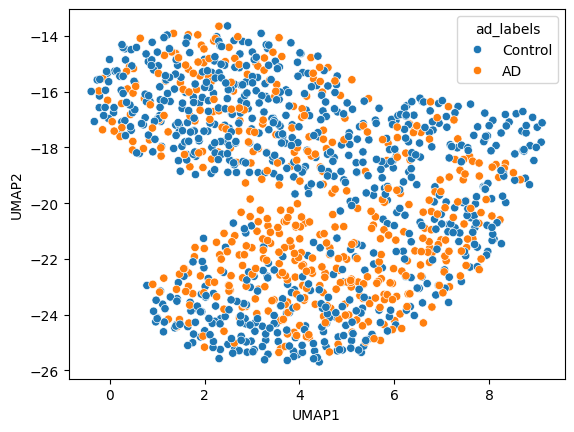

In [287]:
color_mapping_ad = {'Control': '#1f77b4', 'AD': '#ff7f0e'}
sns.scatterplot(x='UMAP1', y='UMAP2', hue='ad_labels', data=embedding_df, palette=color_mapping_ad)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

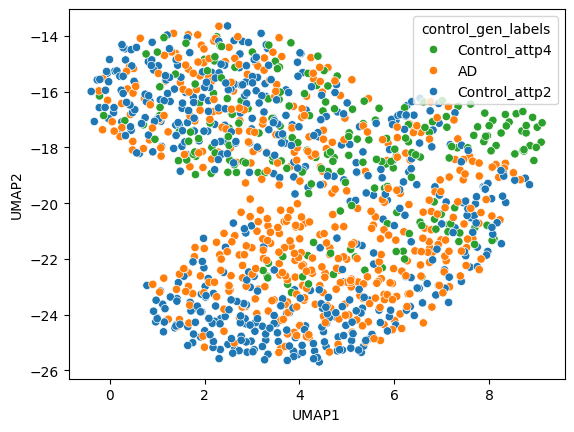

In [288]:
color_mapping_geno = {'Control_attp2': '#1f77b4', 'AD': '#ff7f0e', 'Control_attp4': '#2ca02c'}
sns.scatterplot(x='UMAP1', y='UMAP2', hue='control_gen_labels', data=embedding_df, palette=color_mapping_geno)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

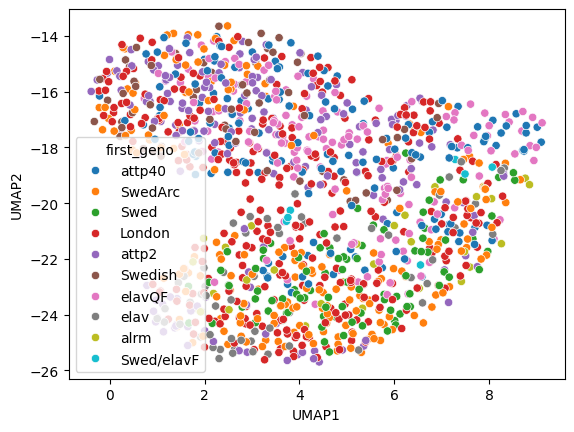

In [281]:
sns.scatterplot(x='UMAP1', y='UMAP2', hue='first_geno', data=embedding_df)

In [289]:
lv500['Sex'] = np.where(
    lv500['genotype'].str.endswith('F'),
    'Female',
    'Male'
)
lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV125,LV126,LV127,LV128,flyID,genotype,AD,Control_Geno,Sex,first_geno
0,1.372615,-2.079071,5.314517,6.346415,3.576416,-1.511956,13.916572,3.237187,2.446653,9.822103,...,-0.195801,-2.545389,4.856113,-1.145381,M119_M49_Ch17,attp40xQAb42_M,Control,Control_attp4,Male,attp40
1,12.870952,-30.186596,27.765068,19.202953,22.676650,-22.796015,24.650703,16.509928,11.280396,12.122602,...,6.152559,-0.207645,21.302590,-30.802023,M106_M15_Ch8,SwedArcxrepo_3_M,AD,AD,Male,SwedArc
2,-7.010117,-24.002570,19.727152,-12.044909,1.467783,10.002118,-3.067422,-8.279963,9.121579,-3.207766,...,-6.480107,6.861367,-9.932140,10.678501,M96_M54_Ch13,Swed>alrmvF,AD,AD,Female,Swed
3,-20.637516,-33.254578,7.722467,-24.153288,-23.682230,18.356077,-2.066006,-11.588375,23.544813,-17.878270,...,10.628320,-10.362025,-0.183787,-3.416682,M96_M50_Ch13,London>alrmM,AD,AD,Male,London
4,-8.765019,-44.824562,20.930141,-20.153719,8.746166,-9.228594,4.001735,20.520327,21.903850,-9.818920,...,8.119950,35.634987,5.488190,-26.430626,M96_M80_Ch28,SwedArc>attp2F,Control,Control_attp2,Female,SwedArc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,1.368336,-2.058063,5.298338,6.323928,3.655330,-1.549236,13.986897,3.312454,2.478303,9.852919,...,-0.204519,-2.554927,4.940231,-1.059543,M106_M4_Ch7,elavQFxattp2_3_M,Control,Control_attp2,Male,elavQF
1202,-12.949490,-38.931873,14.013873,-5.880270,-7.589905,28.981504,-10.009447,-10.760073,30.640478,-12.308589,...,16.461529,0.888287,5.972688,8.814487,M96_M49_Ch6,SwedArc>alrmM,AD,AD,Male,SwedArc
1203,-14.463966,-36.135525,39.011154,-8.450185,41.692772,28.389236,9.482563,0.711522,33.966220,-70.960250,...,20.689125,39.036194,-4.522789,-34.537490,M96_M55_Ch6,elav>attp2M,Control,Control_attp2,Male,elav
1204,-10.379683,-40.197040,29.526674,-14.197499,27.535234,11.361604,-17.857355,11.637393,9.008867,-29.252937,...,0.156714,23.721394,-17.021849,-10.091519,M96_M79_Ch3,London>attp2vF,Control,Control_attp2,Female,London


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

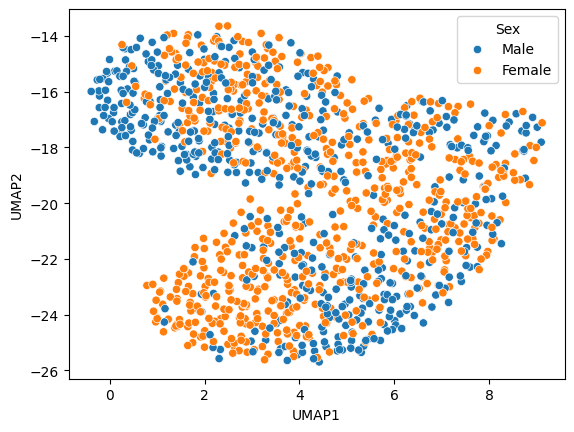

In [290]:
embedding_df['Sex'] = lv500['Sex']
color_mapping_sex = {'Male': '#1f77b4', 'Female': '#ff7f0e'}
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Sex', data=embedding_df, palette=color_mapping_sex)

In [269]:
embedding_df['geno_sex_combined'] = embedding_df['control_gen_labels'].astype(str) + '_' + embedding_df['Sex'].astype(str)
embedding_df

,UMAP1,UMAP2,ad_labels,control_gen_labels,id,Sex,geno_sex_combined
0,25.983543,80.204971,Control,Control_attp4,M119_M49_Ch17,Male,Control_attp4_Male
1,33.283257,75.743759,AD,AD,M106_M15_Ch8,Male,AD_Male
2,22.962042,80.993996,AD,AD,M96_M54_Ch13,Female,AD_Female
3,23.411022,81.759087,AD,AD,M96_M50_Ch13,Male,AD_Male
4,20.310701,81.798370,Control,Control_attp2,M96_M80_Ch28,Female,Control_attp2_Female
...,...,...,...,...,...,...,...
1201,29.374510,82.109879,Control,Control_attp2,M106_M4_Ch7,Male,Control_attp2_Male
1202,23.003119,83.015259,AD,AD,M96_M49_Ch6,Male,AD_Male
1203,19.939798,82.944061,Control,Control_attp2,M96_M55_Ch6,Male,Control_attp2_Male
1204,20.746239,81.769371,Control,Control_attp2,M96_M79_Ch3,Female,Control_attp2_Female


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

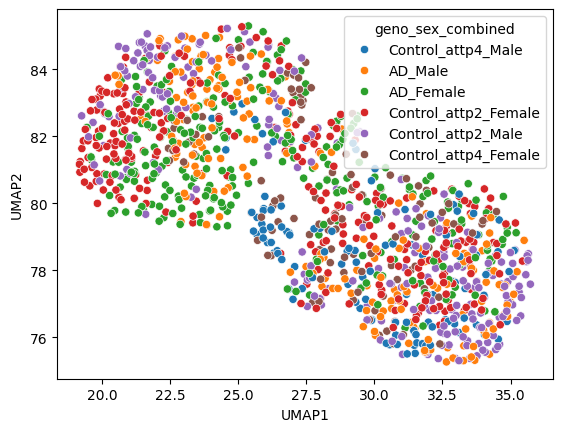

In [270]:
sns.scatterplot(x='UMAP1', y='UMAP2', hue='geno_sex_combined', data=embedding_df)

In [ ]:
delimiter_pattern = r'[x>]'


K-means clustering on the latent space

In [142]:
from sklearn.cluster import KMeans

In [143]:
embedding_df

,UMAP1,UMAP2,ad_labels,control_gen_labels,id,Sex,geno_sex_combined
0,-32.760147,-111.480286,AD,AD,M96_M8_Ch19,Female,AD_Female
1,-29.118502,-115.567223,AD,AD,M106_M29_Ch16,Female,AD_Female
2,-35.163845,-112.352371,Control,Control_attp2,M96_M79_Ch3,Female,Control_attp2_Female
3,-36.042736,-114.204666,AD,AD,M96_M9_Ch13,Female,AD_Female
4,-25.806044,-115.677704,Control,Control_attp2,M106_M30_Ch3,Male,Control_attp2_Male
...,...,...,...,...,...,...,...
1358,-31.349199,-112.458908,AD,AD,M96_M48_Ch2,Male,AD_Male
1359,-33.437546,-111.140633,Control,Control_attp2,M96_M29_Ch29,Female,Control_attp2_Female
1360,-32.419792,-113.469604,AD,AD,M96_M49_Ch5,Male,AD_Male
1361,-27.011635,-115.646637,AD,AD,M153_M28_Ch30,Female,AD_Female


In [144]:
num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init='auto')
kmeans.fit(embedding_df.iloc[:, 0:2])
kmeans.labels_

array([1, 0, 1, ..., 1, 0, 0], dtype=int32)

In [145]:
embedding_df['kmeans_labels'] = kmeans.labels_

In [146]:
embedding_df

,UMAP1,UMAP2,ad_labels,control_gen_labels,id,Sex,geno_sex_combined,kmeans_labels
0,-32.760147,-111.480286,AD,AD,M96_M8_Ch19,Female,AD_Female,1
1,-29.118502,-115.567223,AD,AD,M106_M29_Ch16,Female,AD_Female,0
2,-35.163845,-112.352371,Control,Control_attp2,M96_M79_Ch3,Female,Control_attp2_Female,1
3,-36.042736,-114.204666,AD,AD,M96_M9_Ch13,Female,AD_Female,1
4,-25.806044,-115.677704,Control,Control_attp2,M106_M30_Ch3,Male,Control_attp2_Male,0
...,...,...,...,...,...,...,...,...
1358,-31.349199,-112.458908,AD,AD,M96_M48_Ch2,Male,AD_Male,1
1359,-33.437546,-111.140633,Control,Control_attp2,M96_M29_Ch29,Female,Control_attp2_Female,1
1360,-32.419792,-113.469604,AD,AD,M96_M49_Ch5,Male,AD_Male,1
1361,-27.011635,-115.646637,AD,AD,M153_M28_Ch30,Female,AD_Female,0


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

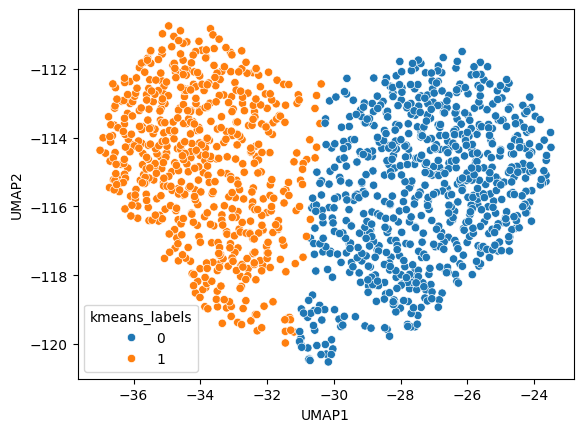

In [147]:
sns.scatterplot(x='UMAP1', y='UMAP2', hue='kmeans_labels', data=embedding_df)

In [148]:
recons500 = pd.read_csv('results/VanillaVAE/recons_epoch5000.csv')
recons500

,0,1,2,3,4,5,6,7,8,9,...,5009,5010,5011,5012,5013,5014,5015,5016,flyID,genotype
0,-0.382268,-0.416469,-0.339633,-0.432821,-0.428790,-0.398372,-0.479876,-0.383444,-0.425087,-0.480681,...,0.888508,1.074368,1.130586,0.793659,0.457330,1.283267,1.030822,1.399170,M96_M8_Ch19,London>nsybG4F
1,-0.395413,-0.407939,-0.374635,-0.441226,-0.437879,-0.402175,-0.477252,-0.401892,-0.423860,-0.464834,...,-0.402920,-0.446762,-0.385003,-0.480359,-0.401795,-0.431822,-0.464956,0.095295,M106_M29_Ch16,elavQFxQA42_1_F
2,-0.403418,-0.431120,-0.357039,-0.420735,-0.432170,-0.405825,-0.472292,-0.405304,-0.431999,-0.459302,...,0.666472,0.652862,0.248374,0.405940,0.427932,0.218593,0.402121,0.948288,M96_M79_Ch3,London>attp2vF
3,-0.406053,-0.429659,-0.364827,-0.431190,-0.420132,-0.414524,-0.459827,-0.422559,-0.420877,-0.458591,...,0.216014,0.441043,0.032019,0.167549,0.208054,-0.227608,-0.010472,0.481314,M96_M9_Ch13,London>nsybG4vF
4,-0.395651,-0.422059,-0.338910,-0.429505,-0.437788,-0.377453,-0.489128,-0.392269,-0.436273,-0.467481,...,-0.393942,3.228556,0.284437,-0.489765,-0.192539,-0.408352,-0.258543,-0.050867,M106_M30_Ch3,attp2xQA40_1_M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,-0.437254,-0.423146,-0.358594,-0.433268,-0.431778,-0.403123,-0.483631,-0.405555,-0.429028,-0.474800,...,1.348987,1.967663,1.588803,0.606138,1.531788,0.629873,1.298814,2.480987,M96_M48_Ch2,elav>SwedArcM
1359,-0.401193,-0.428594,-0.345148,-0.426302,-0.428044,-0.420619,-0.460699,-0.425251,-0.413600,-0.456137,...,-0.386706,-0.472548,-0.394718,0.615217,-0.242132,-0.472944,1.481433,0.060649,M96_M29_Ch29,attp2>nsybG4F
1360,-0.407524,-0.423386,-0.366539,-0.432314,-0.427014,-0.397061,-0.465472,-0.413118,-0.423513,-0.458402,...,-0.398089,-0.389681,-0.350027,-0.456607,-0.411590,-0.431809,-0.440936,-0.358098,M96_M49_Ch5,SwedArc>alrmM
1361,-0.393149,-0.422044,-0.351190,-0.440473,-0.418572,-0.399163,-0.453075,-0.425759,-0.446811,-0.470663,...,-0.439399,-0.444637,-0.407969,-0.491299,-0.438018,-0.451733,-0.464604,-0.340848,M153_M28_Ch30,NaN


In [149]:
final_beam_break_csv = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_standardized_binned.csv')
final_beam_break_csv

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [150]:
raw_beam_binned = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_binned.csv')
raw_beam_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [151]:
input_clustered = pd.merge(raw_beam_binned, embedding_df[['id', 'kmeans_labels']], left_on='FlyID', right_on='id')
input_clustered

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016,id,kmeans_labels
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,M106_M118_Ch25,0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,M106_M118_Ch26,0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,M106_M118_Ch27,0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0,M106_M118_Ch28,0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0,M106_M118_Ch29,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0,M96_M48_Ch28,1
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0,M96_M48_Ch29,1
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0,M96_M48_Ch30,1
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0,M96_M48_Ch31,1


In [152]:
input_clustered['kmeans_labels'] == 1

0       False
1       False
2       False
3       False
4       False
        ...  
1201     True
1202     True
1203     True
1204     True
1205     True
Name: kmeans_labels, Length: 1206, dtype: bool

In [153]:
input_clustered.iloc[:, 2:-3]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5006,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0


In [154]:
input_clustered['mean_beam_breaks'] = np.mean(input_clustered.iloc[:, 2:-3], axis=1) 
input_clustered['std_beam_breaks'] = np.std(input_clustered.iloc[:, 2:-3], axis=1) 
input_clustered

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5011,t5012,t5013,t5014,t5015,t5016,id,kmeans_labels,mean_beam_breaks,std_beam_breaks
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,M106_M118_Ch25,0,1.953349,5.742305
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,M106_M118_Ch26,0,2.101276,4.433977
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,M106_M118_Ch27,0,2.563596,5.732428
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,3.0,6.0,27.0,4.0,0.0,M106_M118_Ch28,0,2.394737,4.215638
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,8.0,7.0,4.0,0.0,M106_M118_Ch29,0,2.630781,6.063565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,8.0,7.0,6.0,7.0,7.0,M96_M48_Ch28,1,3.233652,4.484250
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,10.0,8.0,10.0,9.0,6.0,M96_M48_Ch29,1,4.590710,5.168686
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,3.0,3.0,M96_M48_Ch30,1,3.341906,4.448602
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,10.0,1.0,5.0,3.0,M96_M48_Ch31,1,3.252392,4.394910


In [155]:
input_clustered[input_clustered['kmeans_labels']==0]['mean_beam_breaks'].mean(), input_clustered[input_clustered['kmeans_labels']==1]['mean_beam_breaks'].mean()


(1.7323077856544675, 2.1855604827709225)

In [156]:
input_clustered[input_clustered['kmeans_labels']==0]['mean_beam_breaks'].std(), input_clustered[input_clustered['kmeans_labels']==1]['mean_beam_breaks'].std()

(1.0890753929683674, 1.3248367744736822)

In [157]:
cluster_one_nonzero_counts = input_clustered[input_clustered[input_clustered['kmeans_labels'] == 1].iloc[:, 2:-4] > 0].values.flatten()
np.nanmean(cluster_one_nonzero_counts)

6.503450018389042

In [158]:
cluster_zero_nonzero_counts = input_clustered[input_clustered[input_clustered['kmeans_labels'] == 0].iloc[:, 2:-4] > 0].values.flatten()
np.nanmean(cluster_zero_nonzero_counts)

5.7797694052069

In [159]:
#np.histogram(cluster_zero_nonzero_counts, bins=50)

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


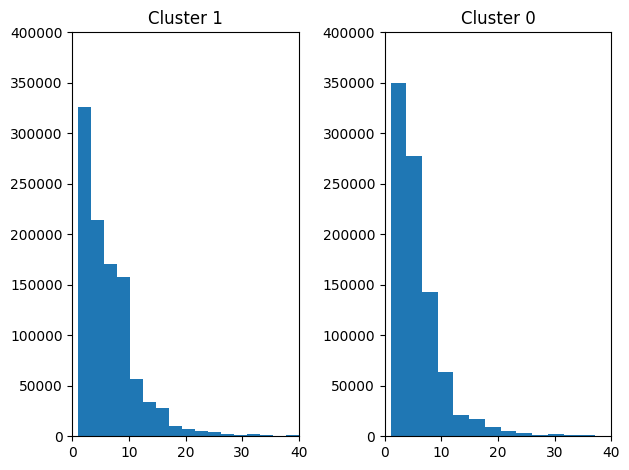

In [160]:
fig, ax = plt.subplots(1, 2)
ax[0].hist(cluster_one_nonzero_counts, bins=80)
ax[0].set_xlim(0, 40)
ax[0].set_ylim(0, 400000)
ax[0].set_title('Cluster 1')
ax[1].hist(cluster_zero_nonzero_counts, bins=110)
ax[1].set_xlim(0, 40)
ax[1].set_ylim(0, 400000)
ax[1].set_title('Cluster 0')
plt.tight_layout()

In [161]:
final_beam_break_csv.iloc[:, 2:].max().max(), final_beam_break_csv.iloc[:, 2:].min().min()

(307.0, 0.0)

In [162]:
mu500 = pd.read_csv('results/VanillaVAE/mu_epoch200.csv')
mu500

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-4.899948,-8.621999,-11.730217,24.213032,18.092121,-16.076147,13.682308,18.360760,41.093388,3.759350,...,-15.159458,7.119585,-4.613115,-16.049282,-18.325272,-38.277847,17.183596,-15.831275,-11.072281,7.637673
1,29.511456,4.448758,25.254429,-28.297884,10.697037,11.879043,35.999893,0.839741,20.953024,0.519489,...,-4.143198,-11.236390,-10.290129,-12.651611,-2.238405,3.849706,4.917780,-49.978900,9.024992,-12.265188
2,-2.552153,-11.627781,-7.159281,13.405445,-5.944987,4.123476,19.834220,-4.781444,23.309898,12.770491,...,-10.392237,-6.770020,5.030108,7.296623,-15.155315,-15.522226,-1.649261,-11.877630,5.621772,-2.418614
3,-4.814313,7.645466,-3.592789,6.283518,0.778681,-1.117245,13.949400,7.768291,8.107460,3.696124,...,3.732996,-3.647811,1.905141,3.811278,-3.422533,-12.725715,11.263973,-13.101427,-5.544420,-4.621710
4,-4.601532,-2.797480,-1.068467,-9.377666,-6.108597,-13.207927,9.530042,5.145223,4.167169,-0.282006,...,10.697547,-7.002482,-11.444991,9.527151,-9.876206,-5.457542,-0.974034,-16.941025,6.050874,-5.375779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,-2.364329,-2.532756,-7.648271,4.490838,-3.158127,-8.508785,-2.737927,2.636593,6.953062,-5.000066,...,2.297938,6.903445,-1.457964,11.194198,-9.705835,-7.930544,11.106983,-3.791995,-4.496693,-14.645544
1359,-2.040408,-4.783365,-9.432457,3.577651,-0.450899,-16.606073,1.038089,6.435212,8.693590,-3.535425,...,3.185607,7.120449,-13.619132,6.568584,-7.413757,-10.300199,5.010514,-2.926119,-12.685638,-9.233334
1360,4.984407,-3.403373,-17.725754,11.834738,-7.529163,-7.100331,27.070677,4.456432,29.077930,0.112494,...,1.746387,-5.018911,-4.005056,0.461395,-13.281498,-14.603584,-1.219751,-24.538883,1.732597,-7.272746
1361,0.853135,-17.968159,-18.462002,28.026900,-12.426405,-9.743254,13.082251,-22.755657,56.075058,23.917690,...,-4.717196,-20.281810,-3.656292,-0.857710,-23.794685,-16.180895,10.908031,-25.899914,8.501320,-9.383949


/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


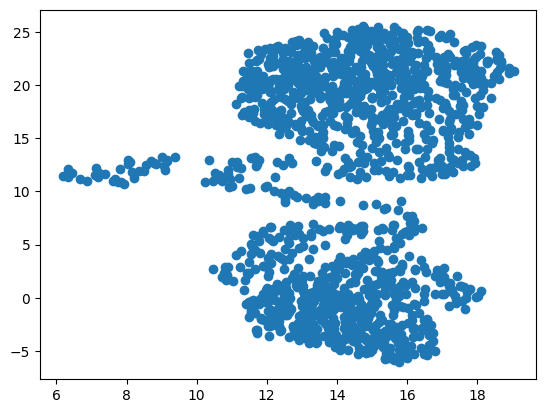

In [163]:
reducer = umap.UMAP(n_neighbors=10, min_dist=1, n_components=2, random_state=40)
embedding = reducer.fit_transform(mu500)
plt.scatter(embedding[:, 0], embedding[:, 1])

Looking at results from full model analysis: 

In [164]:
full_model_lv500 = pd.read_csv('results/VanillaVAE_fullDataset/latent_variables_epoch500.csv')
full_model_lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV121,LV122,LV123,LV124,LV125,LV126,LV127,LV128,flyID,genotype
0,1.543647,-24.907022,29.862345,21.244736,2.765858,-15.334001,-3.829912,2.019461,-14.822165,-6.932077,...,-6.372535,56.244100,-3.947405,-14.197448,0.056011,4.438136,23.361470,1.506371,M96_M56_Ch5,alrm>attp2M
1,42.172398,-48.891150,0.616116,11.309356,-32.428560,-12.941435,36.731716,-24.642340,-12.952911,-25.917270,...,23.747477,23.448158,5.709500,0.982781,23.954859,13.279687,10.995637,24.421734,M96_M8_Ch9,London>nsybG4M
2,9.085712,-30.031796,-36.905228,10.610207,-38.014970,22.202866,6.462127,4.146664,-36.320393,32.989334,...,20.556402,1.457325,-2.868862,-2.531604,-1.276303,73.240610,-8.635896,-48.237946,M153_M30_Ch1,NaN
3,49.129910,-16.624557,-24.391973,-21.466587,-43.129790,34.401260,20.842306,-1.273769,-28.241566,17.031391,...,-0.883835,-13.334839,4.689399,23.950160,1.054714,40.339622,-36.159360,-21.259250,M106_M119_Ch8,attp2xrepo_3_M
4,48.093678,-8.671165,-32.124325,-26.816725,-20.021387,37.645905,-0.127199,18.317265,-14.467728,25.052141,...,3.196025,-12.790665,11.126735,-6.163234,4.007268,38.595795,20.257927,-7.844771,M106_M7_Ch21,elavQFxQA40_3_M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,80.126080,-30.778564,-8.702822,-11.641334,-34.194440,6.564182,36.611015,-48.684784,-25.524094,-7.902217,...,6.867984,19.501905,27.738937,2.693898,28.510027,12.701663,-34.320686,9.303285,M96_M8_Ch6,London>nsybG4M
1359,56.372597,-51.587616,-28.949175,1.797746,-50.872902,24.995338,74.354270,-43.464330,-19.586302,-33.832910,...,3.275878,20.413593,18.040388,-5.880757,33.663414,33.248367,-9.878550,24.037617,M96_M8_Ch13,London>nsybG4M
1360,19.686995,-44.395260,-7.663640,24.299553,-30.540106,-6.831563,23.239082,-36.712080,6.058197,-25.812565,...,-17.350850,-1.512506,15.053123,-15.454806,6.662057,-1.970032,-11.510146,29.945660,M96_M49_Ch11,SwedArc>alrmM
1361,30.531492,-7.308827,-31.041468,4.869783,-15.852768,-4.150526,29.336567,-10.435385,-51.861618,-5.943660,...,12.161571,36.827312,45.184383,-22.331274,22.862797,31.721432,-10.845954,-39.445957,M153_M29_Ch21,NaN


<Axes: xlabel='LV10', ylabel='Density'>

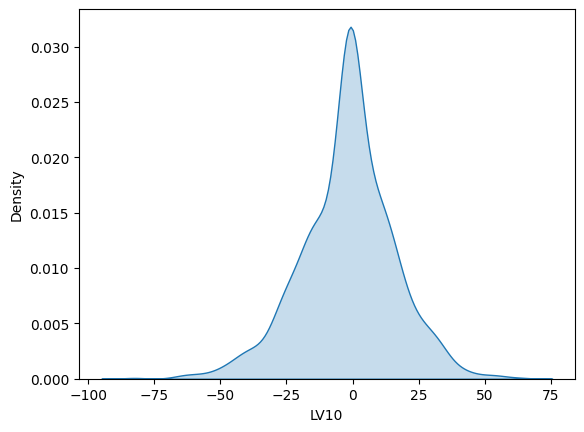

In [165]:
sns.kdeplot(x=full_model_lv500['LV10'], fill=True)

In [166]:
full_model_lv500['Control_Geno'] = np.where(
    full_model_lv500['genotype'].str.contains('attp2', case=False, na=False),
    'Control_attp2',
    np.where(
        full_model_lv500['genotype'].str.contains('attp4', case=False, na=False),
        'Control_attp4',
        'AD'
    )
)

In [167]:
full_model_lv500['AD'] = np.where(
    (full_model_lv500['genotype'].str.contains('attp2', case=False, na=False)) | (full_model_lv500['genotype'].str.contains('attp4', case=False, na=False)), 
    'Control', 
    'AD')
full_model_lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV123,LV124,LV125,LV126,LV127,LV128,flyID,genotype,Control_Geno,AD
0,1.543647,-24.907022,29.862345,21.244736,2.765858,-15.334001,-3.829912,2.019461,-14.822165,-6.932077,...,-3.947405,-14.197448,0.056011,4.438136,23.361470,1.506371,M96_M56_Ch5,alrm>attp2M,Control_attp2,Control
1,42.172398,-48.891150,0.616116,11.309356,-32.428560,-12.941435,36.731716,-24.642340,-12.952911,-25.917270,...,5.709500,0.982781,23.954859,13.279687,10.995637,24.421734,M96_M8_Ch9,London>nsybG4M,AD,AD
2,9.085712,-30.031796,-36.905228,10.610207,-38.014970,22.202866,6.462127,4.146664,-36.320393,32.989334,...,-2.868862,-2.531604,-1.276303,73.240610,-8.635896,-48.237946,M153_M30_Ch1,NaN,AD,AD
3,49.129910,-16.624557,-24.391973,-21.466587,-43.129790,34.401260,20.842306,-1.273769,-28.241566,17.031391,...,4.689399,23.950160,1.054714,40.339622,-36.159360,-21.259250,M106_M119_Ch8,attp2xrepo_3_M,Control_attp2,Control
4,48.093678,-8.671165,-32.124325,-26.816725,-20.021387,37.645905,-0.127199,18.317265,-14.467728,25.052141,...,11.126735,-6.163234,4.007268,38.595795,20.257927,-7.844771,M106_M7_Ch21,elavQFxQA40_3_M,AD,AD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,80.126080,-30.778564,-8.702822,-11.641334,-34.194440,6.564182,36.611015,-48.684784,-25.524094,-7.902217,...,27.738937,2.693898,28.510027,12.701663,-34.320686,9.303285,M96_M8_Ch6,London>nsybG4M,AD,AD
1359,56.372597,-51.587616,-28.949175,1.797746,-50.872902,24.995338,74.354270,-43.464330,-19.586302,-33.832910,...,18.040388,-5.880757,33.663414,33.248367,-9.878550,24.037617,M96_M8_Ch13,London>nsybG4M,AD,AD
1360,19.686995,-44.395260,-7.663640,24.299553,-30.540106,-6.831563,23.239082,-36.712080,6.058197,-25.812565,...,15.053123,-15.454806,6.662057,-1.970032,-11.510146,29.945660,M96_M49_Ch11,SwedArc>alrmM,AD,AD
1361,30.531492,-7.308827,-31.041468,4.869783,-15.852768,-4.150526,29.336567,-10.435385,-51.861618,-5.943660,...,45.184383,-22.331274,22.862797,31.721432,-10.845954,-39.445957,M153_M29_Ch21,NaN,AD,AD


In [168]:
full_model_lv500['Sex'] = np.where(
    full_model_lv500['genotype'].str.endswith('F'),
    'Female',
    'Male'
)
full_model_lv500

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV124,LV125,LV126,LV127,LV128,flyID,genotype,Control_Geno,AD,Sex
0,1.543647,-24.907022,29.862345,21.244736,2.765858,-15.334001,-3.829912,2.019461,-14.822165,-6.932077,...,-14.197448,0.056011,4.438136,23.361470,1.506371,M96_M56_Ch5,alrm>attp2M,Control_attp2,Control,Male
1,42.172398,-48.891150,0.616116,11.309356,-32.428560,-12.941435,36.731716,-24.642340,-12.952911,-25.917270,...,0.982781,23.954859,13.279687,10.995637,24.421734,M96_M8_Ch9,London>nsybG4M,AD,AD,Male
2,9.085712,-30.031796,-36.905228,10.610207,-38.014970,22.202866,6.462127,4.146664,-36.320393,32.989334,...,-2.531604,-1.276303,73.240610,-8.635896,-48.237946,M153_M30_Ch1,NaN,AD,AD,Female
3,49.129910,-16.624557,-24.391973,-21.466587,-43.129790,34.401260,20.842306,-1.273769,-28.241566,17.031391,...,23.950160,1.054714,40.339622,-36.159360,-21.259250,M106_M119_Ch8,attp2xrepo_3_M,Control_attp2,Control,Male
4,48.093678,-8.671165,-32.124325,-26.816725,-20.021387,37.645905,-0.127199,18.317265,-14.467728,25.052141,...,-6.163234,4.007268,38.595795,20.257927,-7.844771,M106_M7_Ch21,elavQFxQA40_3_M,AD,AD,Male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,80.126080,-30.778564,-8.702822,-11.641334,-34.194440,6.564182,36.611015,-48.684784,-25.524094,-7.902217,...,2.693898,28.510027,12.701663,-34.320686,9.303285,M96_M8_Ch6,London>nsybG4M,AD,AD,Male
1359,56.372597,-51.587616,-28.949175,1.797746,-50.872902,24.995338,74.354270,-43.464330,-19.586302,-33.832910,...,-5.880757,33.663414,33.248367,-9.878550,24.037617,M96_M8_Ch13,London>nsybG4M,AD,AD,Male
1360,19.686995,-44.395260,-7.663640,24.299553,-30.540106,-6.831563,23.239082,-36.712080,6.058197,-25.812565,...,-15.454806,6.662057,-1.970032,-11.510146,29.945660,M96_M49_Ch11,SwedArc>alrmM,AD,AD,Male
1361,30.531492,-7.308827,-31.041468,4.869783,-15.852768,-4.150526,29.336567,-10.435385,-51.861618,-5.943660,...,-22.331274,22.862797,31.721432,-10.845954,-39.445957,M153_M29_Ch21,NaN,AD,AD,Female


In [169]:
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=40)
full_embedding = reducer.fit_transform(full_model_lv500.iloc[:, :-5])
full_embedding_df = pd.DataFrame(full_embedding, columns=['UMAP1', 'UMAP2'])
full_embedding_df['ad_labels'] = full_model_lv500['AD']
full_embedding_df['control_gen_labels'] = full_model_lv500['Control_Geno']
full_embedding_df['id'] = full_model_lv500['flyID']
full_embedding_df

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,ad_labels,control_gen_labels,id
0,-37.308495,40.175083,Control,Control_attp2,M96_M56_Ch5
1,-36.087803,36.258202,AD,AD,M96_M8_Ch9
2,-40.715614,36.438328,AD,AD,M153_M30_Ch1
3,-42.117180,34.431892,Control,Control_attp2,M106_M119_Ch8
4,-42.798271,36.445530,AD,AD,M106_M7_Ch21
...,...,...,...,...,...
1358,-34.751038,35.826565,AD,AD,M96_M8_Ch6
1359,-34.637341,34.922146,AD,AD,M96_M8_Ch13
1360,-34.857235,38.762428,AD,AD,M96_M49_Ch11
1361,-41.361546,38.931908,AD,AD,M153_M29_Ch21


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

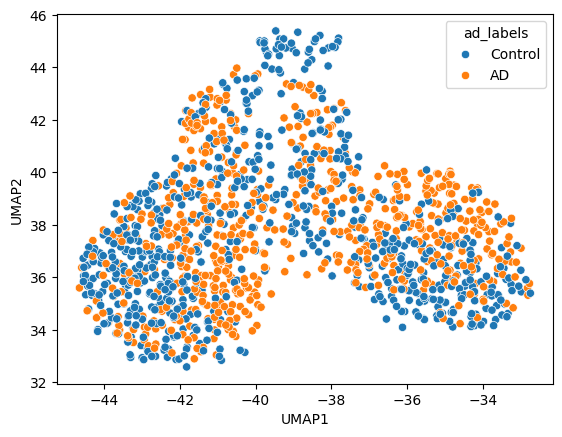

In [170]:
sns.scatterplot(x='UMAP1', y='UMAP2', hue='ad_labels', data=full_embedding_df, palette=color_mapping_ad)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

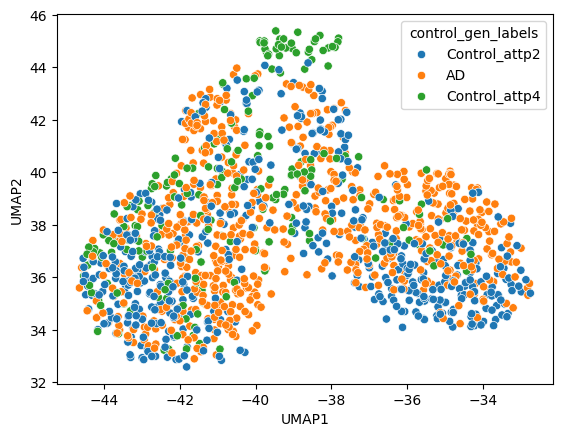

In [171]:
sns.scatterplot(x='UMAP1', y='UMAP2', hue='control_gen_labels', data=full_embedding_df, palette=color_mapping_geno)

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

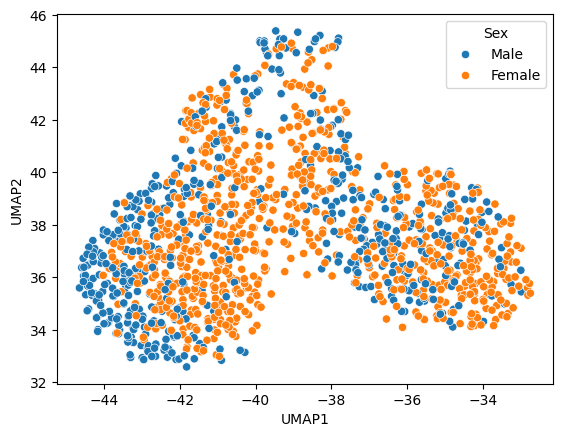

In [172]:
full_embedding_df['Sex'] = full_model_lv500['Sex']
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Sex', data=full_embedding_df, palette=color_mapping_sex)